# **Loan approval Prediction**


Loan approval is an important process that helps financial institutions evaluate whether an applicant is capable of making a reliable repayment commitment. By assessing factors such as income, credit history, and financial background, loan approval systems help reduce the risk of unsuitable lending decisions.

This project will focus on finding an efficient Machine Learning model to help us predict if a user can be approved to take a loan for a house. We will focus on three main models and compare them together. The models will be Logistic Regression, Decision tree and random forest.

Exploratory Data Analysis (EDA) will be performed to gain more knowledge on the features included in our dataset and their relationships together. Next, some feature engineering and preprocessing techniques will be applied before training our models and comparing them to find the best performing model amongst the ones that were chosen for this project. 


## Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

## Loading and understanding the data

In this section we will investigate our columns/features at a basic level to gain some information on our dataset. Metrics such as Shape, duplicates, Unique values in Categorical and etc will be looked at.

In [3]:
df = pd.read_csv('../data/loan_approval_dataset.csv')

In [4]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
print(f"number of rows: {df.shape[0]} \nnumber of columns: {df.shape[1]}")

number of rows: 4269 
number of columns: 13


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


The dataset consists of 4269 rows and 13 columns. The target variable is **loan_status which** has **Approved** and **Rejected** to show the status. A breif discription of all the columns can be found below.

**featuers:**

| Feature | Description | Data Type |
|---------|-------------|-----------|
|loan_id|unique Id for each loan|Numerical|
|no_of_dependents|Level of education of the applicant|Numerical|
|education|Level of education of the applicant|Categorical|
|self_employed|Showing if the applicant is self employed or not|Binary (Yes, No)|
|income_annum|Anual income of the applicant|Numerical|
|loan_amount|The amount of loan the applicant has taken|Numerical|
|loan_term|The term of the loan in years|Numerical|
|cibil_score|The credit score of the applicant|Numerical|
|residential_assets_value|The value of the applicants residential assets|Numerical|
|commercial_assets_value|The value of the applicants commercial assets|Numerical|
|luxury_assets_value|The value of the applicants luxury assets|Numerical|
|bank_asset_value|The value of the applicants bank assets|Numerical|
|loan_status|Showing the status of the loan (**Target Variable**)|Binary (Approved, Rejected)|

A small problem was found with the column name, almost all of them have an extra empty space in the beginning.

In [7]:
print(df.columns)

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')


Let's have a look at all of the unique values that our categorical features have, and statistical summary of our numerical features and check for duplicates and null values.

In [8]:
print(f"education: {df[" education"].unique().tolist()}")
print(f"self_employed: {df[" self_employed"].unique().tolist()}")
print(f"loan_status: {df[" loan_status"].unique().tolist()}")

education: [' Graduate', ' Not Graduate']
self_employed: [' No', ' Yes']
loan_status: [' Approved', ' Rejected']


In [9]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

The categorical features were find to have a minor  formatting inconsistencies due to leading whitespace, similar to the issue found in column names. The statistical summary does not bring any concern; However, it has been reaveld that they are on differnet scales and scalling is needed before training our Logestic Regression model. Moreover, the dataset contains no duplicate or missing record.

## Data cleaning

in the previous section, it was found that column names and values in the categorical features had a leading whitspace issue. To resolve we will take care of this problem in this section by removing them.

In [12]:
df.columns = df.columns.str.strip()


In [13]:
print(df.columns)

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')


In [14]:
df["education"] = df["education"].str.strip()
df["self_employed"] = df["self_employed"].str.strip()
df["loan_status"] = df["loan_status"].str.strip()

In [15]:
print(f"education: {df["education"].unique().tolist()}")
print(f"self_employed: {df["self_employed"].unique().tolist()}")
print(f"loan_status: {df["loan_status"].unique().tolist()}")

education: ['Graduate', 'Not Graduate']
self_employed: ['No', 'Yes']
loan_status: ['Approved', 'Rejected']


As seen above the leading whitesapce issue has been resolved.

## Exploratory Data Analysis (EDA)

In this section exploratory data analysis will be conducted investigate feature and target variables by plotting charts to better understand the dataset and find hidden patternres and gain insight into relationship between variables. The analysis will include a feature analysis by investigating individual feature distributions and relationships between features, a target analysis by checking the distribution of the target variable and feature-to-target relationships, and a correlation heatmap to examine the relationships among the numerical features.

In [16]:
# setting the style
sns.set_style("whitegrid")

### Feature Analysis

in this subsection we will take a look at our features by looking at indvidual distributions and some realtionship between features.

#### Individual feature distributions

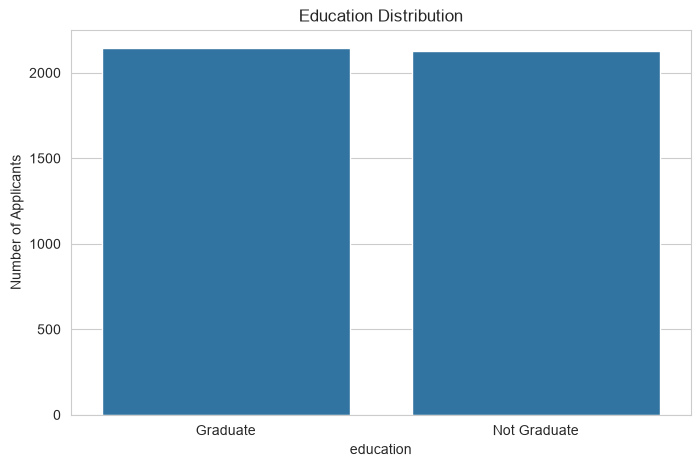

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="education")

plt.ylabel("Number of Applicants")
plt.title("Education Distribution")

plt.show()


The count plot shows the distribution of applicants based on their graduate status. The dataset contains approximately 2,000 applicants in each category, indicating that this feature is well-balanced. This balance reduces the risk of the model being biased towards either graduates or non-graduates during training.

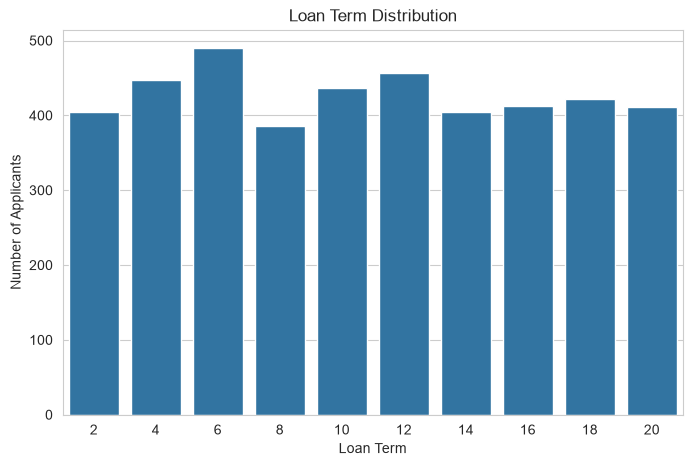

In [18]:

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="loan_term")

plt.ylabel("Number of Applicants")
plt.xlabel("Loan Term")
plt.title("Loan Term Distribution")

plt.show()

This count plot illustrates the number of applicants across the available loan terms. It can be observed that some loan duration are more popular than others. The 6-years plan is the most popular one with approximately 500 applicants followed by the 4, 10 and 12 years terms, each containing 450 applicants by estimate. The remaining terms have around 400 applicants each. Overall, the distribution appears relatively balanced, and none of the terms is dominating the dataset excessively, reducing the chances of machine learning models being biased.

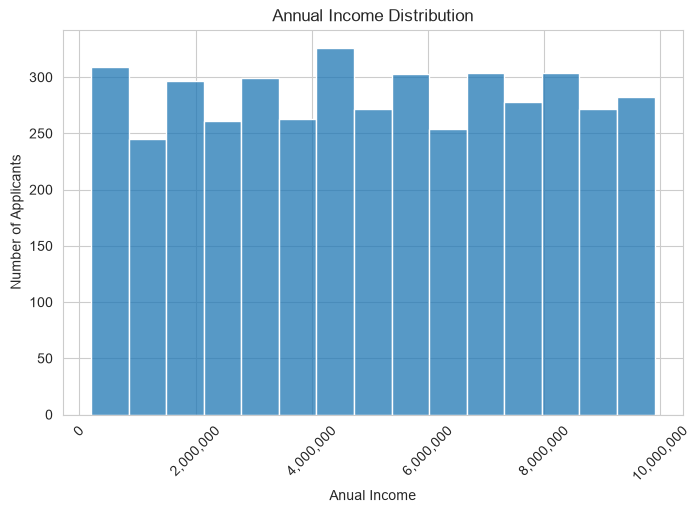

In [19]:
import matplotlib.ticker as ticker

plt.figure(figsize=(8,5))

ax = sns.histplot(data=df, x="income_annum", bins=15)

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45)
plt.ylabel("Number of Applicants")
plt.xlabel("Anual Income")
plt.title("Annual Income Distribution")

plt.show()

This histogram shows the applicants distribution over different ranges of annual income. It can be interpreted number of customers in different income brackets is relatively consistent with no range dominating significantly. To illustrate, the highest range has 350 applicants and the lowest have 250 applicants with the rest of the income brackets having the number of applicants. Overall, the distribution appears to be balanced across all ranges, reducing the chances of machine learning models being biased towards it.

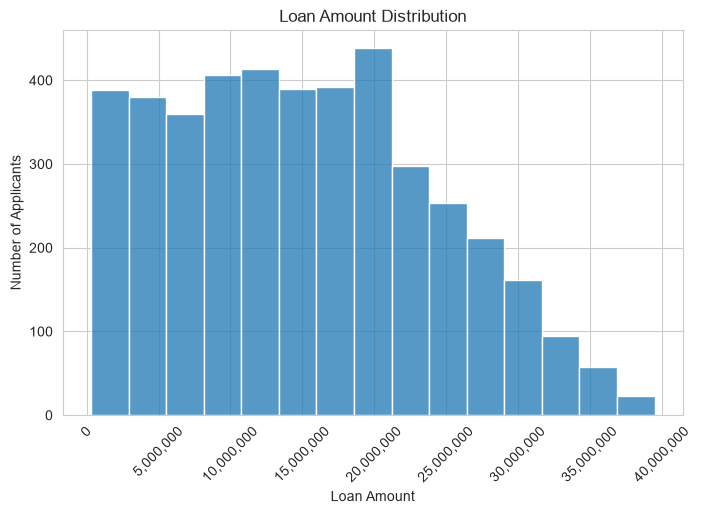

In [20]:
plt.figure(figsize=(8,5))

ax = sns.histplot(data=df, x="loan_amount", bins=15)

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45)
plt.ylabel("Number of Applicants")
plt.xlabel("Loan Amount")
plt.title("Loan Amount Distribution")

plt.show()

This histogram represents the distribution of applicants across different ranges of loan amounts. It can be noticed that there is a drop in number of applicants at 20 million loans, it drops from approximately 450 in the previous bracket to under 300 in the next bracket. All the ranges before that point maintain a high number of applicants ranging from 350 to 400 applicants. However, after that 20 million bracket all the applicant numbers in every range keep decreasing as the loan amount goes higher.  Overall, this could mean higher loan amounts are less frequent and they can be the minority in our dataset and as a result might not be optimal for predicting higher amount loans. 

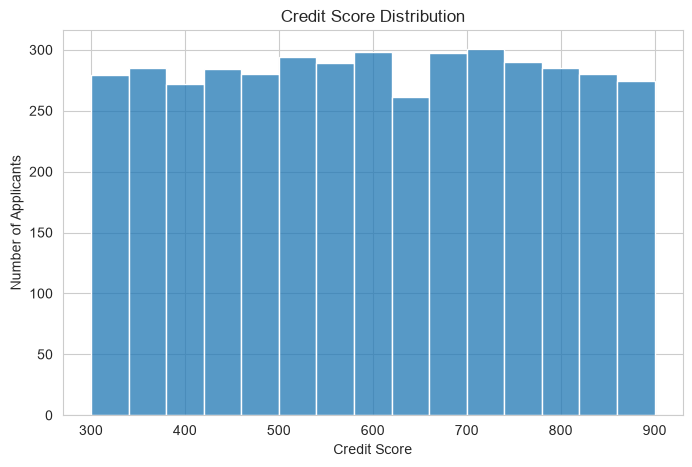

In [21]:

plt.figure(figsize=(8,5))

sns.histplot(data=df, x="cibil_score", bins=15)

plt.ylabel("Number of Applicants")
plt.xlabel("Credit Score")
plt.title("Credit Score Distribution")

plt.show()

This histogram shows the population of applicants in different ranges of credit scores. From the chart it has been revealed that the distribution of users among all ranges is almost equal with 270 to 300 applicants in all ranges by an estimate with one exception of 630 to 690. This range has 240 applicants, which compared to rest of the range it is not of significance. Overall, the distribution of credit scores in our dataset is even as a result it will most probably not cause biases when passed to machine learning models. 

#### Relationships between features

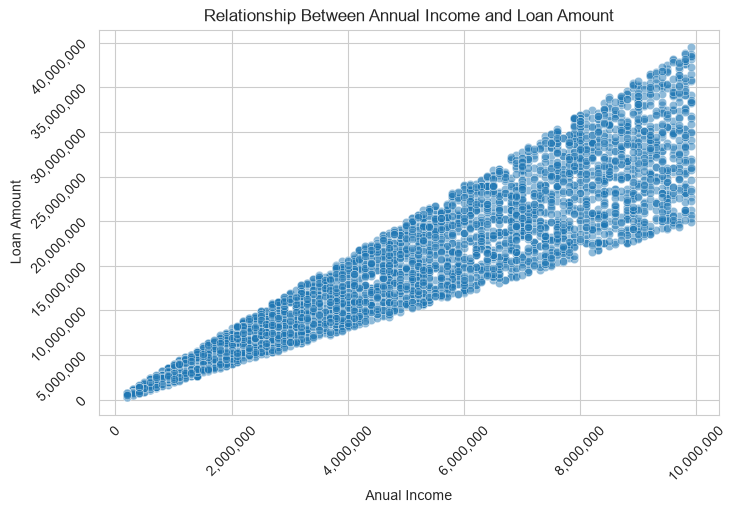

In [22]:
plt.figure(figsize=(8,5))

ax = sns.scatterplot(data=df, x="income_annum", y='loan_amount',alpha= 0.5)

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.yticks(rotation=45)

plt.xlabel("Anual Income")
plt.ylabel("Loan Amount")

plt.title("Relationship Between Annual Income and Loan Amount")



plt.show()

This scatter plot shows both the loan amount and the annual income of all applicants. It illustrates that all of the applicants are within a certain range of income and loan amount and there are no outliers. Also, lower income applicants have smaller loan amounts request with narrower range of loan amounts. For example, at income of 4 million the loan amounts are between 5.5 million to 15 million. However, as income increases both the range and the minimum amount of loan requests also goes up. To Illustrate, at 10 million income applicants can be find with loan amount from 20 to 40 million. Overall, the scatter plot suggests a positive relationship between annual income and loan amount.

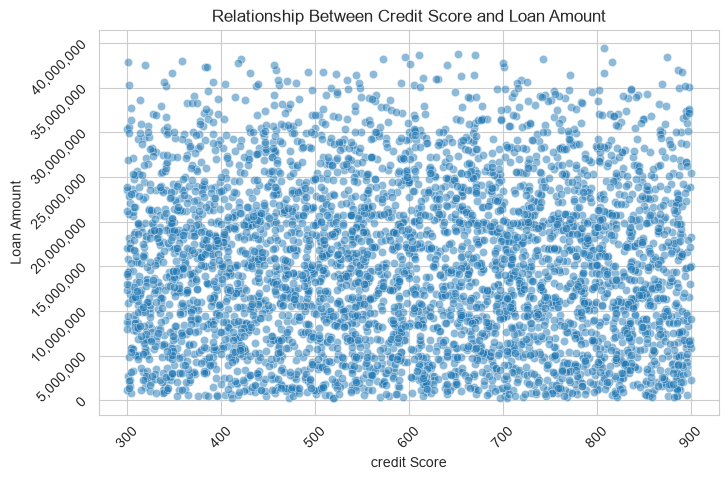

In [23]:
plt.figure(figsize=(8,5))

ax = sns.scatterplot(data=df, x="cibil_score", y='loan_amount', alpha= 0.5)

plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.yticks(rotation=45)

plt.xlabel("credit Score")
plt.ylabel("Loan Amount")

plt.title("Relationship Between Credit Score and Loan Amount")



plt.show()

This scatter plot illustrates the relationship between credit score and loan amount. Unlike the previous chart, no clear trend is visible between these two factors. Applicants with both high and low credit score requests loans with wide ranges of values. Moreover, no cluster or grouping can also be seen suggesting the loan amount is not heavily influenced by the applicant’s credit score alone. This metric will be further investigated in model training.

### Traget analysis

In this subsection we will take on an analytic turn on our target by looking at its distributaion and relationship with other features.

#### Target distribution

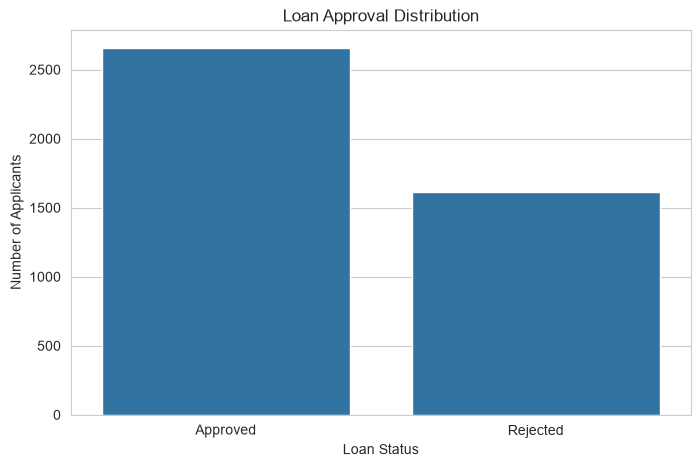

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="loan_status")

plt.ylabel("Number of Applicants")
plt.xlabel("Loan Status")
plt.title("Loan Approval Distribution")

plt.show()

This chart demonstrates the distribution of applicants across two statuses for loan, approved and rejected. The chart illustrates that the approved group seem to have more applicants in them compared to rejected applicants. To be more specific, there are approximately 2500 approved applicants and 1500 rejected ones. Overall, the distribution of applicants across these two groups imbalanced to a very small amount and increases chances of machine learning models developing bias towards the majority group. As a result, other metrics such as recall need to be examined.

#### Feature to target relationships

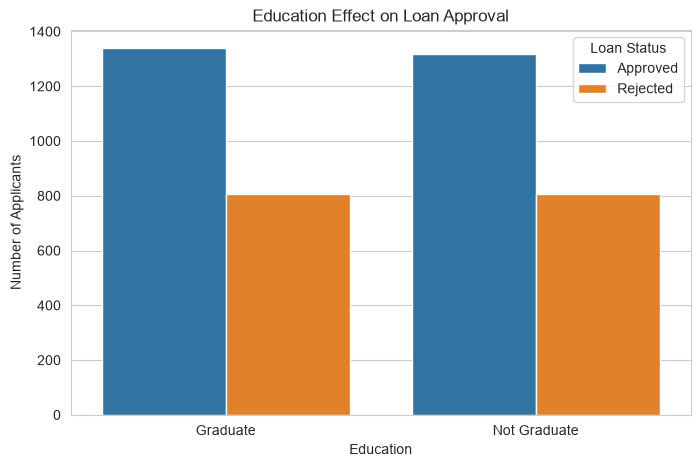

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="education", hue="loan_status")

plt.ylabel("Number of Applicants")
plt.xlabel("Education")
plt.title("Education Effect on Loan Approval")
plt.legend(title="Loan Status")

plt.show()

This chart shows the distribution of loan approval outcomes across applicants with graduate and non-graduate education levels. A similar pattern can be seen in both education groups. Approved loans have a higher number of applicants in both groups at 1370 compared to rejected at 800 applicants.  Overall, the chart supports the fact that graduate applicants make up a larger proportion of the dataset and loan approvals are more common than rejections in both education groups.

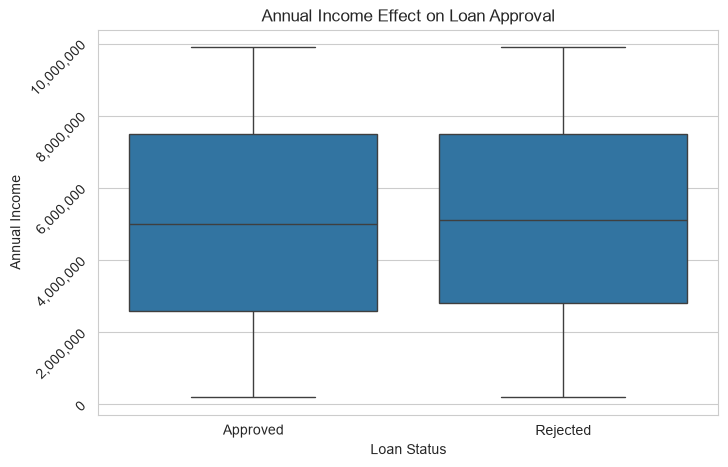

In [26]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(data=df, x="loan_status" ,y="income_annum")

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.yticks(rotation=45)

plt.ylabel("Annual Income")
plt.xlabel("Loan Status")

plt.title("Annual Income Effect on Loan Approval")

plt.show()

The box plot compares the distribution of annual income between approved and rejected loan applicants. The charts show that both groups have similar median for annual income at 5 million. Similarly, both group’s 50% middle box spread from approximately 2.5 million to 7.5 million of income and maximum and minimum incomes of close to 0 and 10 million. Overall, it can be concluded that due to the overlapping of the boxes and similarity of the median it can be suggested that the annual income on its own does not have a strong relationship with applicants’ approval or rejection of the loan. 

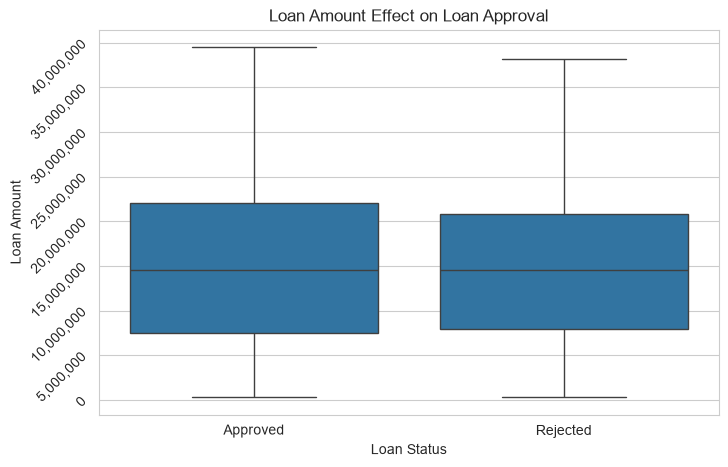

In [27]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(data=df, x="loan_status" ,y="loan_amount")

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.yticks(rotation=45)

plt.ylabel("Loan Amount")
plt.xlabel("Loan Status")

plt.title("Loan Amount Effect on Loan Approval")

plt.show()

The boxplot illustrates the difference between distribution of loan amount between approved and rejected applicants of loan. Similarly to the previous chart for annual income effect on loan status, it can be observed that both groups have very similar medians, which is approximately 15 million and the interquartile boxes overlap significantly, both ranging from slightly below 10 million to slightly above 20 million. However, approved applicants seem to have a minor higher upper range on both the upper limit of the interquartile box and the maximum compared to rejected clients. Overall, this suggests that there is not a strong relationship between loan status and loan amount just alone. 

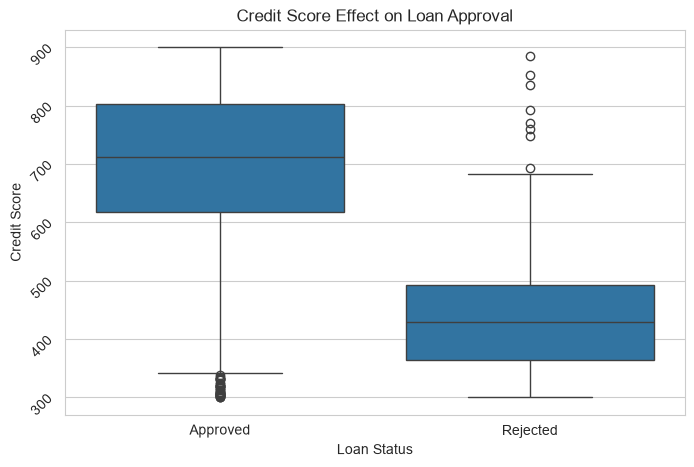

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="loan_status" ,y="cibil_score")

plt.yticks(rotation=45)

plt.ylabel("Credit Score")
plt.xlabel("Loan Status")

plt.title("Credit Score Effect on Loan Approval")

plt.show()

This boxplot shows and compares the distribution that credit score has over approved and rejected applicants on loans. It is visible that approved clients have a considerably higher median, at slightly over 700, compared to rejected applicants at approximately 430. Furthermore, the interquartile of the two groups show little overlap. Approved applicants have a credit score range of slightly over 600 to 800 while rejected client’s range is 380 to 500. There are some potential outliers in both groups. Overall, all of this suggests that there is a strong association between loan approval status and the applicant’s credit score and is expected to be an important feature in our prediction algorithms.

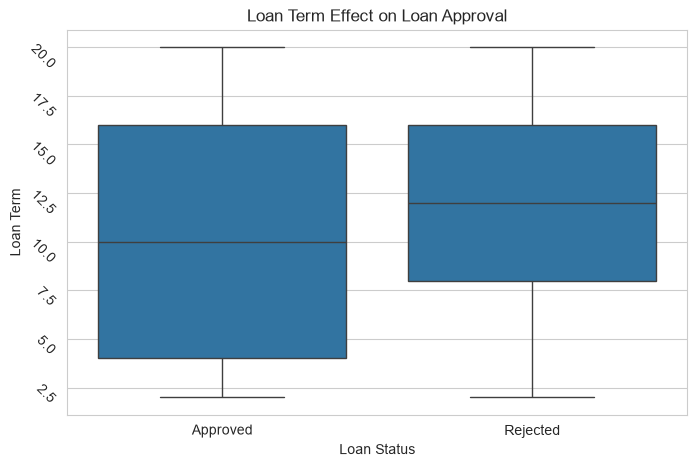

In [29]:

plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="loan_status" ,y="loan_term")

plt.yticks(rotation=-45)

plt.ylabel("Loan Term")
plt.xlabel("Loan Status")

plt.title("Loan Term Effect on Loan Approval")

plt.show()

The boxplot compares the distribution of loan terms between approved and rejected loan applicants. The rejected group has a slightly higher median for loan terms, at approximately 12 years, compared with 10 years for the approved group. The 50% box for the approved group has a wider spread from almost 4 years to 16 years, while the rejected group has a range between approximately 7.5 to 16 years. Moreover, both groups have same overall ranges from almost 2 years to 20. Overall, the distributions overlap quite a lot suggesting that the loan term itself might not be able to distinguish between approved and rejected applicants. However, the higher median in rejected can suggest some correlation which can be further investigated in model training. 

## Feature Engineering 

In this section we will investigate our feature more and try to create new useful ones and delete the unrelated ones based on correct reasoning to gain more insight towards each applicant’s financial position, repayment capacity, and potential credit risk more directly.

a new `dataFrame` will be made the hold all of the new created features and the original ones. 

First and foremost, the loan_id column adds no value to the prediction so it should be dropped.

In [30]:
df.drop(columns=['loan_id'], inplace= True)

In [31]:
df_engineered = df.copy()

First feature we will be making is `loan_income_ratio` which will be created by dividing each loan amount by the income of the applicants. This might give a better insight on how repaying ability of the applicant. Both of these features were shown to may not have a big influence on the prediction in our EDA. However, combining them might give us a better measure which will be investigated further. 

In [32]:
df_engineered['loan_income_ratio'] = df_engineered['loan_amount'] / df_engineered['income_annum']

Our next feature to create will be `total_assets`.  This feature will be created by adding residential, commercial, luxury and bank assets together to give as a better insight on the financial wealth of the applicant. 

In [33]:
df_engineered['total_assets'] = (
    df_engineered['residential_assets_value']
    + df_engineered['commercial_assets_value'] 
    + df_engineered['luxury_assets_value'] 
    + df_engineered['bank_asset_value']
)

Next, we will be creating `loan_asset_ratio` feature. This feature was created by dividing the loan amount by the total assets of the applicant representing that ratio, to help us measure the amount of financial support in assets that is associated to the loan. 

In [34]:
df_engineered['loan_assets_ratio'] = df_engineered['loan_amount'] / df_engineered['total_assets']

Moreover, we will now create ` income_per_dependent`. This is goingto help us have an estimate on the income of each dependent by dividing the annual income by the number of dependents plus 1 to avoid dividing by zero and count for the person getting the loan too. 

In [35]:
df_engineered['income_per_dependent'] = df_engineered['income_annum'] / (df_engineered['no_of_dependents'] + 1)

`annual_loan_burden` is going to be the next feature we will be making. This will help us measure the amount of loan associated with each year and the burden that it will put on the applicant.

In [36]:
df_engineered['annual_loan_burden'] = df_engineered['loan_amount'] / df_engineered['loan_term']

Another feature we will create is `cibil_income_interaction`.  This feature has been created to by mulplying credit score and annual income to potentially help us find the effect that these two features might have together on loan approval. 

In [37]:
df_engineered['cibil_income_interaction'] = df_engineered['cibil_score'] * df_engineered['income_annum']

Six new features have been made that are trying to make new useful information for our prediction. The usefulness of some of these measures will be analyzed in in the next sections. 

## Preprocessing

In this section we will be splitting our features and target, define our test and train sets using Train Test Split encode categorical features and scale the numeric columns as Logistic Regression works better with scaled numbers. We will also have two sets of features, one will include the new features created in the previous section and one will only include the original ones.

### Train test split 

We will have to separate features and targets and do our train test split before encoding and scaling to avoid data leakage and this subsection focuses on this. There will also be two test and train sets one with the original dataset and one with the engineered one that we have created.

In [38]:
X = df.drop(columns=['loan_status'])
X_eng = df_engineered.drop(columns=['loan_status'])
y = df['loan_status']

X_train_org, X_test_org, X_train_eng, X_test_eng, y_train, y_test = train_test_split(X, X_eng, y, train_size=0.8, random_state=42)

In [39]:
print("sizes:")
print(f"\t-Original Training features: {X_train_org.shape}")
print(f"\t-Original Testing features: {X_test_org.shape}")
print(f"\t-Engineered Training features: {X_train_eng.shape}")
print(f"\t-Engineered Testing features: {X_test_eng.shape}")
print(f"\t-Training target: {y_train.shape}")
print(f"\t-Testing target: {y_test.shape}")

sizes:
	-Original Training features: (3415, 11)
	-Original Testing features: (854, 11)
	-Engineered Training features: (3415, 17)
	-Engineered Testing features: (854, 17)
	-Training target: (3415,)
	-Testing target: (854,)


The dataset has been successfully split features and tartget and further into training (80%) and testing (20%) sets. The training set will be used to fit the model, while the testing set will be reserved for evaluating its performance on unseen data.

### Encoding

The education column needs encoding and as the values inside the column do not have an order to them we will be using `OneHotEncoder`. Moreover, self_employed column also do need encoding. However this column is made of yes and no and the order in them suggests using `OrdinalEncoder`.

In [40]:
# the encoder has been set to turn the output into a pd dataframe for ease of concating 
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')

trn_education_train = ohe.fit_transform(X_train_org[['education']])
trn_education_test = ohe.fit_transform(X_test_org[['education']])

In [41]:
print("sizes:")
print(f"\t-Encoded education train: {trn_education_train.shape}")
print(f"\t-Encoded education test: {trn_education_test.shape}")

sizes:
	-Encoded education train: (3415, 2)
	-Encoded education test: (854, 2)


The encoded dataFrames are the correct size we expected so both the orignal and engineered train and test sets features need to be updated.

In [42]:
X_train_org = pd.concat([X_train_org, trn_education_train], axis=1).drop(columns=['education'])
X_train_eng = pd.concat([X_train_eng, trn_education_train], axis=1).drop(columns=['education'])

X_test_org = pd.concat([X_test_org, trn_education_test], axis=1).drop(columns=['education'])
X_test_eng = pd.concat([X_test_eng, trn_education_test], axis=1).drop(columns=['education'])

In [43]:
print("sizes:")
print(f"\t-Original Training features: {X_train_org.shape}")
print(f"\t-Original Testing features: {X_test_org.shape}")
print(f"\t-Engineered Training features: {X_train_eng.shape}")
print(f"\t-Engineered Testing features: {X_test_eng.shape}")
print(f"\t-Training target: {y_train.shape}")
print(f"\t-Testing target: {y_test.shape}")

sizes:
	-Original Training features: (3415, 12)
	-Original Testing features: (854, 12)
	-Engineered Training features: (3415, 18)
	-Engineered Testing features: (854, 18)
	-Training target: (3415,)
	-Testing target: (854,)


In [44]:
enc = OrdinalEncoder(categories=[["No", "Yes"]])

X_test_eng['self_employed'] = enc.fit_transform(X_test_eng[['self_employed']])
X_test_org['self_employed'] = enc.fit_transform(X_test_org[['self_employed']])

X_train_eng['self_employed'] = enc.fit_transform(X_train_eng[['self_employed']])
X_train_org['self_employed'] = enc.fit_transform(X_train_org[['self_employed']])

In [45]:
X_test_org.head()

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_Graduate,education_Not Graduate
1703,5,0.0,5400000,19700000,20,423,6500000,10000000,15700000,7300000,1.0,0.0
1173,2,0.0,5900000,14000000,8,599,4700000,9500000,17800000,6700000,1.0,0.0
308,3,0.0,9600000,19900000,14,452,4200000,16200000,28500000,6600000,1.0,0.0
1322,2,0.0,6200000,23400000,8,605,10000000,10800000,21800000,9200000,1.0,0.0
3271,3,1.0,5800000,14100000,12,738,11700000,4400000,15400000,8400000,0.0,1.0


All the sizes are what we are expecting as we have added two new columns and removed the not encoded one, the number of columns have increased by one. Furthermore, an example of one of the test sest is being showed.

### Feature scalling

As we will be using Logistic regression model it is better to scale our features. As a result, we will be making a separate scaled train and test sets for this model

In [46]:
# Scale the numerical features
scaler = StandardScaler()
X_train_eng_scaled = scaler.fit_transform(X_train_eng)
X_train_org_scaled = scaler.fit_transform(X_train_org)

X_test_eng_scaled = scaler.fit_transform(X_test_eng)
X_test_org_scaled = scaler.fit_transform(X_test_org)

## Model Training and Evaluation

In this section we will be training three machine learning models using the original and the feature engineered feature sets that also have been properly preprocessed in the previous sections, evaluating each of them individually on how well they have performed and if the feature engineering increased the predicting capabilities of the model or not. The models we will be working with are, **Logistic Regression**, **Decision Tree** and **Random Forest**.

### Logistic Regression

In this section we will first train a Logestic Regression on our original feature set, followed by the same steps done on our feature engineered set to better understand how will it effect our model in making predictions. 

#### Original features

In [47]:
# this model will be using the original scaled feature set 
logestic_reg1 = LogisticRegression()

In [48]:
logestic_reg1.fit(X_train_org_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [49]:
logestic_reg1.score(X_test_org_scaled, y_test)

0.8992974238875878

In [50]:
logestic_reg1.score(X_train_org_scaled, y_train)

0.9200585651537335

From the accuracy on the training and testing sets, it has been revealed that this logistic regression model is not overfit. To Illustrate, the accuracy on the test set is 89 percent and for the training set is 92 which is slightly higher and understandable, as it is slightly easier for the model to make predictions on the data that it has seen before.

In [51]:
# making a prediction on the test set
logestic_y_pred1 = logestic_reg1.predict(X_test_org_scaled)

In [52]:
print(confusion_matrix(y_test, logestic_y_pred1))

[[498  38]
 [ 48 270]]


The confusion matrix shows that 498 approved loans were correctly classified, while 38 Approved loans were incorrectly predicted as Rejected. Meanwhile, 32 Rejected loans were incorrectly predicted as Approved, while 286 were correctly identified as Rejected. This shows that the model does make some classification errors; however, the number is relatively small compared with total number of predictions. And the false negatives and positives are very close in numbers and show that it is doing a slightly better job on the Approved class.   

In [53]:
print(classification_report(y_test, logestic_y_pred1, digits=3))

              precision    recall  f1-score   support

    Approved      0.912     0.929     0.921       536
    Rejected      0.877     0.849     0.863       318

    accuracy                          0.899       854
   macro avg      0.894     0.889     0.892       854
weighted avg      0.899     0.899     0.899       854



The classification report further supports the confusion matrix. It can be seen that, precision, recall and f1-score on both of the groups are high and promising with a slightly higher numbers in the metrics for the Approved class. These three metrics are approximately around 92 percent for the Approved class and range from 85 to 87 percent for the Rejected class. The slight rise in these metrics for the Approved class can potentially be due to Approved class being the majority in our dataset. Overall, this model has done a good job in predicting both class with a slight favor towards the Approved class. 

#### Engineered feature

In [54]:
# this model will be using the engineered scaled feature set 
logestic_reg2 = LogisticRegression()

In [55]:
logestic_reg2.fit(X_train_eng_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [56]:
logestic_reg2.score(X_test_eng_scaled, y_test)

0.9180327868852459

In [57]:
logestic_reg2.score(X_train_eng_scaled, y_train)

0.9306002928257686

Just like the model trained on the original feature set, this model also shows even higher numbers in accuracy for both the test and train sets while having a very small increase for the accuracy on the train set. Test set has the accuracy of approximately 92 and the train set has 93 percent.

In [58]:
logestic_y_pred2 = logestic_reg2.predict(X_test_eng_scaled)

In [59]:
print(confusion_matrix(y_test, logestic_y_pred2))

[[498  38]
 [ 32 286]]


The confusion matrix is also fairly similar to the previous model which used the original features. However, this model did a slightly better job on the prediction of the Rejected group, with 32 applicants falsely detected as Approved while being Rejected and 286 correctly predicted as Rejected. The numbers for the Approved class have not changed. 

In [60]:
print(classification_report(y_test, logestic_y_pred2, digits=3))

              precision    recall  f1-score   support

    Approved      0.940     0.929     0.934       536
    Rejected      0.883     0.899     0.891       318

    accuracy                          0.918       854
   macro avg      0.911     0.914     0.913       854
weighted avg      0.918     0.918     0.918       854



The classification report shows high numbers in precision, recall and F1-score for both groups to predict. Approved class numbers range from 93 to 94 percent across these metrics with precision being slightly higher than recall. For the Rejected group these metrics range from 90 to 88 percent with recall being almost 90%. Just like the previous Logistic Regression model we had we can see the numbers for Approved class are slightly higher than Rejected, which can be potentially due to Approved being the majority class in our dataset. Overall, this model does a good Job on prediction of loan while doing a very slightly better job on Approved class while being also better than the previous model trained with our original features.

#### Conclusion

The results show that both Logistic Regression models, trained using the original and feature-engineered datasets, performed well on the loan approval classification task. However, the feature-engineered model showed a slight improvement across most evaluation metrics. For the Rejected class, precision, recall, and F1-score increased by approximately 1–5 percentage points. The Approved class also experienced improvements across these metrics, although the changes were smaller, ranging from approximately 1–3 percentage points. Overall, the results suggest that feature engineering provided additional useful information for the Logistic Regression model and slightly improved its predictive performance on this dataset.

### Decision Tree 

in this section we will be training a Deecion Tree model on two feature sets one with new engineered features and one without them to help us understand the effect of our new features added.

#### Original features

In [61]:
# this model will be using the original feature set 
decision_tree1 = DecisionTreeClassifier(random_state=42)

In [62]:
decision_tree1.fit(X_train_org, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [63]:
decision_tree1.score(X_test_org, y_test)

0.9765807962529274

In [64]:
decision_tree1.score(X_train_org, y_train)

1.0

The scores reveal that the model is not overfit because the scores on the test and train sets are not far apart. To illustrate, tes gained a score of 97 percent while train set achieved 100. These numbers do not suggest overfitting of our model. 

In [65]:
dtc_y_pred1 = decision_tree1.predict(X_test_org)

In [66]:
print(confusion_matrix(y_test, dtc_y_pred1))

[[528   8]
 [ 12 306]]


The confusion matrix also shows that the model did a decent job at predicting our groups with 8 mislabeling in approved class and 12 in rejected. Overall, 20 mislabeled data which compared to the size of our test data we had is a good result for our confusion matrix.

In [67]:
print(classification_report(y_test, dtc_y_pred1))

              precision    recall  f1-score   support

    Approved       0.98      0.99      0.98       536
    Rejected       0.97      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854



The classification report supports the results shown in the confusion matrix. The Approved class achieved a precision of 98%, a recall of 99%, and an F1-score of 98%. Similarly, the Rejected class achieved a precision of 98%, a recall of 99%, and an F1-score of 98%. These consistently high scores indicate that the model performed well in identifying both classes and was able to make accurate predictions with relatively few classification errors. Moreover, the optimal performance of the model does not suggest to investigate hyperparameter tunning.

In [68]:
pd.DataFrame(decision_tree1.feature_importances_,index=X_test_org.columns, columns=["Influence"])

,Influence
no_of_dependents,0.003544
self_employed,0.000000
income_annum,0.034906
loan_amount,0.036938
loan_term,0.079202
cibil_score,0.828601
residential_assets_value,0.002495
commercial_assets_value,0.006294
luxury_assets_value,0.006261
bank_asset_value,0.001760


The feature importance results show that cibil_score was by far the most influential feature in the model, with an importance of approximately 0.829. loan_term was the second most influential feature, followed by loan_amount and income_annum, although their importance was considerably lower than that of cibil_score.

In contrast, features such as self_employed, education, bank_asset_value, and no_of_dependents had very low or no measured importance in the model. This suggests that the Decision Tree relied heavily on CIBIL score when making its predictions, while several other features contributed relatively little to the model's decisions.

#### Engineered feature

In [69]:
# this model will be using the engineered feature set 
decision_tree2 = DecisionTreeClassifier(random_state=42)

In [70]:
decision_tree2.fit(X_train_eng, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [71]:
decision_tree2.score(X_test_eng, y_test)

1.0

In [72]:
decision_tree2.score(X_train_eng, y_train)

1.0

The scores reveal that this model which has been trained with the set including our new features is not overfit and has a perfect score of 100 percent for both the test and train set. This illustrates that feature engineering did not heavily affect overfitting as the previous model trained on our original sets were also not overfit. It only helped with the score on the test set to be increased slightly. 

In [73]:
dtc_y_pred2 = decision_tree2.predict(X_test_eng)

In [74]:
print(confusion_matrix(y_test, dtc_y_pred2))

[[536   0]
 [  0 318]]


The confusion matrix shows that this model has not made any classification errors as no false positive or negative can be seen and all our test subjects have been correctly classified. This indicates feature engineering had a meaningful effect on Decision Tree, reaching perfect predictive performance on this specific test set. 

In [75]:
print(classification_report(y_test, dtc_y_pred2))

              precision    recall  f1-score   support

    Approved       1.00      1.00      1.00       536
    Rejected       1.00      1.00      1.00       318

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



The classification report further supports the findings in the confusion matrix by showing perfect score across all evaluation metrics. To illustrate, precision, recall and f1-score across both Approved and Rejected classes are all a perfect 100 percent. Compared to the previous model trained on original features all of the above metrics faced an increase between 1 to 4 percent. 

In [76]:
pd.DataFrame(decision_tree2.feature_importances_,index=X_test_eng.columns, columns=["Influence"])

,Influence
no_of_dependents,0.000000
self_employed,0.000000
income_annum,0.000000
loan_amount,0.000000
loan_term,0.078298
cibil_score,0.819107
residential_assets_value,0.000000
commercial_assets_value,0.000000
luxury_assets_value,0.000000
bank_asset_value,0.000000


Feature importance results in the table show that cibil_score is by far the most influential feature amongst all the features, surpassing in score by a great amount of 0.89. Moreover, the second most influential metric is loan_income_ratio which is one of our engineered features with the score of 0.084 and loan_term has the third place in influence with the score of 0.078. On the other hand, the rest of the features seem to have almost no influence on making the predictions and the model is heavily relied on CIBIL score when making predictions. These results are similar to ones we saw in the previous model. 

#### Conclusion

In conclusion, it has been revealed that both of the models trained with original and feature engineered sets perform well in the task of classifying the approval of a loan. However, the feature engineering was proved to have increased the performance of Decision Tree model in this task. To illustrate, all of the metrics including precision, recall and f1-score for the model using the original dataset ranged from 96 to 99 whereas, the feature-engineered model achieved 100% for all three metrics across both classes. This indicates that the feature-engineered model correctly classified all observations in the test set. Furthermore, the feature importance results showed that one of the newly created features made a meaningful contribution to the model's predictions. This suggests that the engineered feature provided useful additional information and may have contributed to the improved performance of the feature-engineered Decision Tree.